# 00 — DIC data quality and noise study

This notebook inspects noise in the DIC data using the side-loaded-plate dataset utilities.

It covers:
- statistics table (std / bias / RMSE-to-FEM)
- standard deviation + bias figure

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator

from phd.config import load_config
from phd.io import load_side_loaded_plate_reference_raw, create_interpolation_fn
from phd.models.cm.side_loaded_plate import _dataset_filename_from_cfg
from phd.plot import book_config, get_current_config as plt_cfg, KUL_CYCLE
from phd.plot.plot_util import plot_field, add_colorbar

book_config.set_as_current()
page_width = plt_cfg().page_width

save_fig = True
save_table = True
if save_fig:
    mpl.rcParams["pgf.texsystem"] = "pdflatex"


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for parent in [current, *current.parents]:
        if (parent / "pyproject.toml").exists():
            return parent
    raise FileNotFoundError("Could not find project root.")


PROJECT_ROOT = find_project_root(Path.cwd())
CHAPTER_DIR = PROJECT_ROOT / "chapters" / "IV_MaterialCharacterization" / "01_side_loaded_plate"
IMAGE_DIR = CHAPTER_DIR / "images"
PDF_DIR = IMAGE_DIR / "pdf"
TABLE_DIR = CHAPTER_DIR / "tables"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)
PDF_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

DIC_ROOT = PROJECT_ROOT / "src" / "phd" / "io" / "dataset" / "side_loaded_plate" / "dic"

print(f"Project root: {PROJECT_ROOT}")
print(f"DIC root: {DIC_ROOT}")

Using backend: jax
Other supported backends: tensorflow.compat.v1, tensorflow, pytorch, paddle.
paddle supports more examples now and is recommended.
Enable just-in-time compilation with XLA.



Project root: /home/r2d2/code/PhD
DIC root: /home/r2d2/code/PhD/src/phd/io/dataset/side_loaded_plate/dic


In [3]:
def _read_dic_csv(path: Path) -> np.ndarray:
    return pd.read_csv(path, sep=None, engine="python", header=None).dropna(axis=1).to_numpy()


def build_reference_interpolators(length: float = 100.0):
    cfg = load_config("side_loaded_plate")
    cfg.problem.geometry.length = float(length)
    cfg.problem.material.law = "isotropic"

    dataset_name = _dataset_filename_from_cfg(cfg)
    raw = load_side_loaded_plate_reference_raw(dataset_name)

    coords = raw[:, :2]
    u_val = raw[:, 2:4]
    strain_val = raw[:, 4:7]

    x_grid = np.unique(coords[:, 0])
    y_grid = np.unique(coords[:, 1])
    nx, ny = len(x_grid), len(y_grid)

    x_to_i = {float(x): i for i, x in enumerate(x_grid)}
    y_to_j = {float(y): j for j, y in enumerate(y_grid)}

    def reshape_on_grid(values: np.ndarray) -> np.ndarray:
        out = np.zeros((nx, ny, values.shape[1]))
        for k, (xv, yv) in enumerate(coords):
            out[x_to_i[float(xv)], y_to_j[float(yv)], :] = values[k, :]
        return out

    u_grid = reshape_on_grid(u_val)
    strain_grid = reshape_on_grid(strain_val)

    displacement_fn = create_interpolation_fn(x_grid, y_grid, u_grid)
    strain_fn = create_interpolation_fn(x_grid, y_grid, strain_grid)
    return displacement_fn, strain_fn


def list_sample_ids(dic_base: Path, field: str = "ux") -> list[int]:
    return sorted(int(p.stem.split("_")[-1]) for p in (dic_base / field).glob(f"{field}_*.csv"))


def load_dic_sample_2d(dic_base: Path, sample_id: int):
    X = _read_dic_csv(dic_base / "x" / f"x_{sample_id}.csv")
    Y = _read_dic_csv(dic_base / "y" / f"y_{sample_id}.csv")

    fields = {
        "ux": _read_dic_csv(dic_base / "ux" / f"ux_{sample_id}.csv"),
        "uy": _read_dic_csv(dic_base / "uy" / f"uy_{sample_id}.csv"),
        "exx": _read_dic_csv(dic_base / "exx" / f"exx_{sample_id}.csv"),
        "eyy": _read_dic_csv(dic_base / "eyy" / f"eyy_{sample_id}.csv"),
        "exy": _read_dic_csv(dic_base / "exy" / f"exy_{sample_id}.csv"),
    }
    return X, Y, fields


def compute_statistics_for_camera(camera: str, noise: int = 1, length: float = 100.0):
    dic_base = DIC_ROOT / camera / f"{noise}noise"
    sample_ids = list_sample_ids(dic_base)
    if not sample_ids:
        raise ValueError(f"No DIC samples found in {dic_base}")

    disp_fn, strain_fn = build_reference_interpolators(length=length)

    X0, Y0, first_fields = load_dic_sample_2d(dic_base, sample_ids[0])
    points = np.column_stack([X0.ravel(), Y0.ravel()])
    u_ref = disp_fn(points).reshape(*X0.shape, 2)
    e_ref = strain_fn(points).reshape(*X0.shape, 3)
    fem = {
        "ux": u_ref[:, :, 0],
        "uy": u_ref[:, :, 1],
        "exx": e_ref[:, :, 0],
        "eyy": e_ref[:, :, 1],
        "exy": e_ref[:, :, 2],
    }

    stacked = {k: [] for k in first_fields.keys()}
    for sid in sample_ids:
        _, _, fields = load_dic_sample_2d(dic_base, sid)
        for k in stacked:
            stacked[k].append(fields[k])

    stacked = {k: np.stack(v, axis=0) for k, v in stacked.items()}

    stats = {}
    for name, arr in stacked.items():
        mean_arr = np.mean(arr, axis=0)
        std_arr = np.std(arr, axis=0)
        bias_arr = mean_arr - fem[name]
        rmse_arr = np.sqrt(np.mean((arr - fem[name][None, :, :]) ** 2, axis=0))
        stats[name] = {
            "mean": mean_arr,
            "std": std_arr,
            "bias": bias_arr,
            "rmse": rmse_arr,
            "fem": fem[name],
        }

    return {
        "camera": camera,
        "noise": noise,
        "sample_ids": sample_ids,
        "X": X0,
        "Y": Y0,
        "stats": stats,
    }

In [ ]:
from IPython.display import display

camera_list = ["5MP", "2MP", "0.4MP"]
noise_level = 1
results_by_camera = {cam: compute_statistics_for_camera(cam, noise=noise_level, length=100.0) for cam in camera_list}

field_labels = {
    "ux": r"$u_x$",
    "uy": r"$u_y$",
    "exx": r"$\varepsilon_{xx}$",
    "eyy": r"$\varepsilon_{yy}$",
    "exy": r"$\varepsilon_{xy}$",
}


rows = []
for camera, payload in results_by_camera.items():
    for field_name, d in payload["stats"].items():
        rows.append(
            {
                "Camera": camera,
                "Field": field_labels[field_name],
                "Samples": len(payload["sample_ids"]),
                "Mean Std": float(np.mean(d["std"])),
                "Mean |Bias|": float(np.mean(np.abs(d["bias"]))),
                "Mean RMSE": float(np.mean(d["rmse"])),
            }
        )

stats_df = pd.DataFrame(rows)
display(stats_df.style.format({"Mean Std": "{:.3e}", "Mean |Bias|": "{:.3e}", "Mean RMSE": "{:.3e}"}))

if save_table:
    table_path = TABLE_DIR / "dic_noise_statistics.tex"
    stats_df.to_latex(table_path, index=False, float_format="%.3e")
    print(f"Saved: {table_path}")

,Camera,Field,Samples,Mean Std,Mean |Bias|,Mean RMSE
0,5MP,$u_x$,11,4.023e-03,1.272e-03,4.221e-03
1,5MP,$u_y$,11,1.642e-03,5.185e-04,1.724e-03
2,5MP,$\varepsilon_{xx}$,11,8.095e-05,2.565e-05,8.492e-05
3,5MP,$\varepsilon_{yy}$,11,3.476e-05,1.074e-05,3.639e-05
4,5MP,$\varepsilon_{xy}$,11,2.510e-06,1.270e-06,2.926e-06
5,2MP,$u_x$,11,4.029e-03,1.306e-03,4.241e-03
6,2MP,$u_y$,11,1.644e-03,5.319e-04,1.735e-03
7,2MP,$\varepsilon_{xx}$,11,8.086e-05,2.584e-05,8.491e-05
8,2MP,$\varepsilon_{yy}$,11,3.450e-05,1.153e-05,3.642e-05
9,2MP,$\varepsilon_{xy}$,11,2.891e-06,1.899e-06,3.678e-06


Saved: /home/r2d2/code/PhD/chapters/IV_MaterialCharacterization/01_side_loaded_plate/tables/dic_noise_statistics.tex


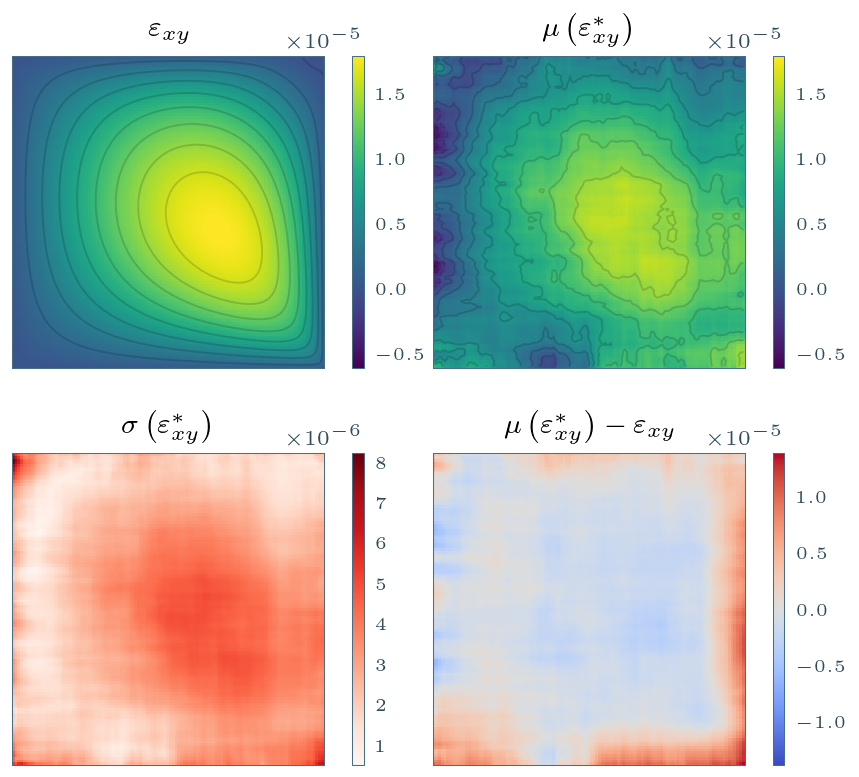

In [28]:
camera_plot = "2MP"
field_plot = "exy"

payload = results_by_camera[camera_plot]
X_dic, Y_dic = payload["X"], payload["Y"]
field_data = payload["stats"][field_plot]

field_symbol = field_labels[field_plot].strip("$")
fem_title = rf"${field_symbol}$"
mean_dic_title = rf"$\mu\left({field_symbol}^*\right)$"
std_dic_title = rf"$\sigma\left({field_symbol}^*\right)$"
bias_title = rf"$\mu\left({field_symbol}^*\right) - {field_symbol}$"

vmin_ref = min(np.nanmin(field_data["fem"]), np.nanmin(field_data["mean"]))
vmax_ref = max(np.nanmax(field_data["fem"]), np.nanmax(field_data["mean"]))
bias_lim = np.nanmax(np.abs(field_data["bias"]))

fig, ax = plt.subplots(2, 2, figsize=(0.8 * page_width, 0.8 * page_width), dpi=250, gridspec_kw={"wspace": 0.35, "hspace": 0.2})

art = plot_field(ax[0, 0], X_dic, Y_dic, field_data["fem"], title=fem_title, cmap="viridis", vmin=vmin_ref, vmax=vmax_ref, plot_contours=True)
add_colorbar(fig, ax[0, 0], art["im"], shift=0.03, size=0.012)

art = plot_field(ax[0, 1], X_dic, Y_dic, field_data["mean"], title=mean_dic_title, cmap="viridis", vmin=vmin_ref, vmax=vmax_ref, plot_contours=True)
add_colorbar(fig, ax[0, 1], art["im"], shift=0.03, size=0.012)

art = plot_field(ax[1, 0], X_dic, Y_dic, field_data["std"], title=std_dic_title, cmap="Reds")
add_colorbar(fig, ax[1, 0], art["im"], shift=0.03, size=0.012)

art = plot_field(
    ax[1, 1],
    X_dic,
    Y_dic,
    field_data["bias"],
    title=bias_title,
    cmap="coolwarm",
    vmin=-bias_lim,
    vmax=bias_lim,
)
add_colorbar(fig, ax[1, 1], art["im"], shift=0.03, size=0.012)

for a in ax.ravel():
    a.set_xticks([])
    a.set_yticks([])

plt.show()

# if save_fig:
#     fig_name = f"dic_noise_{camera_plot}_{field_plot}_std_bias"
#     fig.savefig(IMAGE_DIR / f"{fig_name}.png", dpi=300, bbox_inches="tight")
#     fig.savefig(PDF_DIR / f"{fig_name}.pdf", bbox_inches="tight")
#     print(f"Saved: {IMAGE_DIR / (fig_name + '.png')}")
#     print(f"Saved: {PDF_DIR / (fig_name + '.pdf')}")